# Perform NN-based error correction
NN is trained on syndromes and absolute values of the noisy signals

In [1]:
!pip install pyldpc

     |████████████████████████████████| 1.1 MB 5.4 MB/s 
  Created wheel for pyldpc: filename=pyldpc-0.7.9-py3-none-any.whl size=14319 sha256=e4ae750f879bbc190233a810e007390eaad1df8b991bb9dfa7752a4f08fa5a00
  Stored in directory: /root/.cache/pip/wheels/9b/69/2a/ba5ceb9e99368c3defffb925ed3f17064ce39fc74474d49fbb
Successfully built pyldpc


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os.path, sys, bz2
import pyldpc as ldpc
from tqdm.keras import TqdmCallback
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
def getBinaryMatrix(source):
    source = os.path.expanduser(source)
    fileObj = bz2.BZ2File(source, 'r') if source.endswith('bz2') else open(source, 'rt')
    with fileObj as f:
        lines = [[int(x) for x in l.strip().split()]
                  for l in f.readlines()
                  if len(l.strip()) > 0]

    if lines[0][0] in (0, 1):  # explicit 0/1 representation
        return np.array(lines, dtype=np.int)
    return alistToNumpy(lines)

def alistToNumpy(lines):
    nCols, nRows = lines[0]
    if len(lines[2]) == nCols and len(lines[3]) == nRows:
        startIndex = 4
    else:
        startIndex = 2
    matrix = np.zeros((nRows, nCols), dtype=int)
    for col, nonzeros in enumerate(lines[startIndex:startIndex + nCols]):
        for rowIndex in nonzeros:
            if rowIndex != 0:
                matrix[rowIndex - 1, col] = 1
    return matrix

In [17]:
code_mode = 1;
if code_mode == 0:
  k = 7
  N = 15
  T = 2
  H = getBinaryMatrix('BCH_15_7_2_strip.alist')
elif code_mode == 1:
  k = 39
  N = 63
  T = 4
  H = getBinaryMatrix('BCH_63_39_4_strip.alist')
elif code_mode == 2:
  k = 16
  N = 31
  T = 3
  H = getBinaryMatrix('BCH_31_16_3_strip.alist')

G = ldpc.coding_matrix(H, sparse=False).T

In [18]:
def full_adder(a,b,c):
    s = (a ^ b) ^ c
    c = (a & b) | (c & (a ^ b))
    return s,c

def add_bool(a,b):
    if len(a) != len(b):
        raise ValueError('arrays with different length')
    k = len(a)
    s = np.zeros(k,dtype=bool)
    c = False
    for i in reversed(range(0,k)):
        s[i], c = full_adder(a[i],b[i],c)    
    if c:
        warnings.warn("Addition overflow!")
    return s

def inc_bool(a):
    k = len(a)
    increment = np.hstack((np.zeros(k-1,dtype=bool), np.ones(1,dtype=bool)))
    a = add_bool(a,increment)
    return a

def modulateBPSK(x):
    return -2*x +1

def demodulateBPSK(x):
    return (-(np.sign(x) - 1)/2).astype(int)

def find_syndrome(x):
    return x @ H.T % 2

def errors(y_true, y_pred):
    return keras.backend.sum(int(keras.backend.not_equal(y_true, keras.backend.round(y_pred))))

def errors_RNN(y_true, y_pred):
    if len(y_pred.shape) == 3:
      return keras.backend.sum(int(keras.backend.not_equal(y_true, keras.backend.round(y_pred[:,-1,:]))))
    else:
      return errors(y_true, y_pred)

def reshape_codebook(cb):
    output_shape_test = tf.reshape(cb, (-1, N+N-k, 1))
    return output_shape_test

def make_rnn_input(cb,time_steps=5):
    cb_expand = tf.expand_dims(cb, axis=-2)
    cb_repeat = tf.repeat(cb, repeats=time_steps, axis=-2)
    cb_rnn = tf.reshape(cb_repeat, (-1, time_steps, N+N-k))
    return cb_rnn

output_shape_test = (0, 0, 0)

def gen_set(size=10000, scale=0.82, zero=False):
    """
    Generate train/test set composed of random codewords with defined AWGN level.
    
    Parameters:
    ---------
    set_size: int. Size of the train/test set (number of rows)
    scale: float. Eb/N0 level of AWGN. Default 2dB
    zero: whether is to generate set only from zero-codeword
    
    Returns:
    ---------
    codewords: original codewords
    y: modulated CWs with AWGN
    synd_inputs: syndromes noisy codewords
    abs_inputs: absolute values of noisy codewords
    error_vectors: vector with error incicating bits
    """
    
    # np.random.seed(2)
    noise = np.random.normal(loc=0, scale=scale, size=(size,N))
    rng = np.random.default_rng()
    if zero == False:
        A = np.random.randint(2, size=(size, k))
        codewords_set = A @ G % 2
        #codewords_set = rng.choice(codewords, size, replace=True)
    else:
        codewords_set = np.tile(np.zeros((1,N)), (size, 1))
    y_set = modulateBPSK(codewords_set) + noise
    synd_set = find_syndrome(demodulateBPSK(y_set))
    abs_set= np.abs(y_set)
    error_vectors_set = (codewords_set != demodulateBPSK(y_set)).astype(int)
    return codewords_set, y_set, synd_set, abs_set, error_vectors_set

In [32]:
gen_set(size=2,zero=True)

63
63


(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 array([[-0.12974532,  0.93942293,  0.98270032,  0.00601325,  0.61523979,
         -0.13574031,  1.40576375,  2.72383534,  1.63235477,  1.01831141,
          1.95554225,  1.85509323,  1.96878083,  1.46206004,  1.37548853,
          1.67461655,  1.97592761,  0.63127358,  1.08724995,  1.36782158,
          2.01847135,  0.34672774,  1.93753341, -0.65245329,  2.07403776,
          0.94064585,  0.02338735,  2.81757463,  0

In [24]:
if code_mode != 1:
  inputs = np.zeros((2**k,k),dtype=bool)
  for i in range(1,2**k):
      inputs[i]= inc_bool(inputs[i-1])
  codewords = inputs @ G % 2

In [11]:
N

31

In [38]:
A = np.random.randint(2, size=(10, k))
A @ G % 2

array([[1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
        1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
        0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
        0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
        0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,

## Define NN parameters

In [8]:
class CompressRnnOutput(layers.Layer):

  def __init__(self):
      super(CompressRnnOutput, self).__init__()

  def call(self, inputs, training=None):  # Defines the computation from inputs to outputs
    if training:
      return inputs
    else:
      return inputs[:,-1,:]
    

class RnnCrossEntropy(tf.keras.losses.Loss):

  def call(self, y_true, y_pred):
    if len(y_pred.shape) == 3:
      y_true = tf.cast(y_true, tf.float32)    
      
      T = y_pred.shape[-2]
      N = y_pred.shape[-1]
      gamma = 0.5
      
      y_true_rnn = tf.expand_dims(y_true, axis=-2)

      CE = - y_true_rnn * tf.math.log(y_pred) - (1-y_true_rnn)*tf.math.log(1-y_pred)
      
      gamma_multiplier = tf.reshape( tf.constant([gamma**(T-t) for t in range(T)]), [1,T,1])
      
      CE_weighted = CE * gamma_multiplier
      
      return tf.math.reduce_mean( 1/N * tf.math.reduce_sum(CE_weighted, axis=(-2,-1)) )
    else:
      # For validation
      bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
      return bce(y_true, y_pred)



# Example 1: (batch_size = 1, number of samples = 4)
y_true = tf.constant(np.random.randint(low =0, high = 2, size=[2, 2]), dtype=tf.float32)
y_pred = tf.constant(np.random.uniform(size = [2, 3, 2]), dtype=tf.float32)
rnn_bce = RnnCrossEntropy()
print( rnn_bce(y_true, y_pred).numpy() )

# Example 1: (batch_size = 1, number of samples = 4)
y_true = tf.constant(np.random.randint(low =0, high = 2, size=[2, 2]), dtype=tf.float32)
y_pred = tf.constant(np.random.uniform(size = [2, 2]), dtype=tf.float32)
rnn_bce = RnnCrossEntropy()
print(rnn_bce(y_true, y_pred).numpy() )

# Example 1: (batch_size = 1, number of samples = 4)
y_true = tf.constant(np.array([[[0.3, 0.7],[0.1, 0.8]]]))
y_pred = tf.constant(np.array([[0, 1]]), dtype=tf.float32)
rnn_bce = RnnCrossEntropy()
print(rnn_bce(y_true, y_pred).numpy() )

0.7013205
1.0117092
3.4591498


In [9]:
# Example 1: (batch_size = 1, number of samples = 4)
y_pred = tf.constant(np.array([[[0.3, 0.7],[0.1, 0.8]]]), dtype=tf.float32)
y_true = tf.constant(np.array([[0, 1]]), dtype=tf.float32)
rnn_bce = RnnCrossEntropy()
print(rnn_bce(y_true, y_pred).numpy() )
y_pred = tf.constant(np.array([[[0.1, 0.8],[0.3, 0.7]]]), dtype=tf.float32)
y_true = tf.constant(np.array([[0, 1]]), dtype=tf.float32)
rnn_bce = RnnCrossEntropy()
print(rnn_bce(y_true, y_pred).numpy() )

0.17129476
0.2194005


In [9]:
a = np.array([[0, 1], [0, 1]])
a.shape

(2, 2)

In [11]:
a = 'dd'
b = ['aa', 'bb', 'cc']
b + [a]

['aa', 'bb', 'cc', 'dd']

In [19]:
def update_model(mode):
    
    if mode == 'h-dense':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F = layers.Dense(6*N, activation='relu')(F_input)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])

    elif mode == 'h-lstm':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F_input = layers.Lambda(reshape_codebook, input_shape = (N+N-k,), output_shape = output_shape_test, name = 'reshape')(F_input)
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F_input)
    
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu')(F)
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])
        
    elif mode == 'gru':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F = layers.Lambda(make_rnn_input)(F_input)
        F = layers.GRU(5*N, activation='tanh', return_sequences=True)(F)
        F = layers.GRU(5*N, activation='tanh', return_sequences=True)(F)
        F = layers.GRU(5*N, activation='tanh', return_sequences=True)(F)
        F = layers.GRU(N, activation='sigmoid', return_sequences=True)(F)
        noise_pred = CompressRnnOutput()(F)
        #noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])

        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])
        model.compile(optimizer=keras.optimizers.Adam(), loss=RnnCrossEntropy(), metrics=errors_RNN)
        return model

    elif mode == 'gru_simplified':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F = layers.Lambda(make_rnn_input)(F_input)
        F = layers.GRU(5*N, activation='tanh', return_sequences=True)(F)
        F = layers.GRU(5*N, activation='tanh', return_sequences=True)(F)
        F = layers.GRU(5*N, activation='tanh', return_sequences=True)(F)
        F = layers.GRU(5*N, activation='tanh')(F)
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])


    elif mode == 'dense':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F = layers.Dense(6*N, activation='relu')(F_input)
        F = layers.Dense(5*N, activation='relu')(F)
        F = layers.Dense(4*N, activation='relu')(F)
        F = layers.Dense(3*N, activation='relu')(F)
        F = layers.Dense(2*N, activation='relu')(F)
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
    model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])
    model.compile(optimizer=keras.optimizers.Adam(), loss=keras.losses.BinaryCrossentropy(), metrics=errors)

    return model

# NVE calculation

In [ ]:
# Define set of training SNRs
train_SNR_dB_start_Eb = -5
train_SNR_dB_stop_Eb = 5
train_SNR_points = 20

train_SNR_dB_start_Es = train_SNR_dB_start_Eb + 10*np.log10(k/N)
train_SNR_dB_stop_Es = train_SNR_dB_stop_Eb + 10*np.log10(k/N)

train_sigma_start = np.sqrt(1/(2*10**(train_SNR_dB_start_Es/10)))
train_sigma_stop = np.sqrt(1/(2*10**(train_SNR_dB_stop_Es/10)))
train_sigmas = np.linspace(train_sigma_start, train_sigma_stop, train_SNR_points)
train_SNR_Eb = np.linspace(train_SNR_dB_start_Eb, train_SNR_dB_stop_Eb, train_SNR_points)

# Define set of test SNRs
SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 5
SNR_points = 15

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

In [ ]:
# base params
mode = 'gru'

train_size = 100000
val_size =   10000
test_batch = 100000
n_upd = 1         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nve_nb_errors = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)
nve_nb_errors_NN = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)
nve_nb_frame_errors = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)
nve_nb_frame_errors_NN = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)

for tr_sig_i, tr_sig in enumerate(train_sigmas):
#     Fit model
    nve_eval_model = update_model(mode)


    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=30, min_lr=0.0001)

    checkpoint_filepath = "nve_calculation/gru_nve_calculation_SNR_" + str(tr_sig)
    model_checkpoint_callback_nve_calculation = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_weights_only=True,
      monitor='val_loss',
      mode='min',
      save_best_only=True)

    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, scale=tr_sig)
        nve_eval_model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            verbose=0, 
            validation_split = 0.2,
            callbacks=[TqdmCallback(verbose=0),
                       model_checkpoint_callback_nve_calculation,
                       reduce_lr])
    nve_eval_model.load_weights(checkpoint_filepath)
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(nve_eval_model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nve_nb_frame_errors[tr_sig_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nve_nb_frame_errors_NN[tr_sig_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nve_nb_errors[tr_sig_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nve_nb_errors_NN[tr_sig_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{tr_sig_i+1}/{len(train_sigmas)} train, {sig_i+1}/{len(sigmas)} test', end='\r')


0epoch [00:00, ?epoch/s]

KeyboardInterrupt: ignored

In [ ]:
# base params
mode = 'gru_simplified'

train_size = 100000
val_size =   10000
test_batch = 100000
n_upd = 1         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nve_nb_errors = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)
nve_nb_errors_NN = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)
nve_nb_frame_errors = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)
nve_nb_frame_errors_NN = np.zeros((len(train_sigmas),len(sigmas)),dtype=int)

for tr_sig_i, tr_sig in enumerate(train_sigmas):
#     Fit model
    nve_eval_model = update_model(mode)


    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=30, min_lr=0.0001)

    checkpoint_filepath = "grus_nve_calculation/gru_nve_calculation_SNR_" + str(tr_sig)
    model_checkpoint_callback_nve_calculation = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_weights_only=True,
      monitor='val_loss',
      mode='min',
      save_best_only=True)

    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, scale=tr_sig)
        nve_eval_model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            verbose=0, 
            validation_split = 0.2,
            callbacks=[TqdmCallback(verbose=0),
                       model_checkpoint_callback_nve_calculation,
                       reduce_lr])
    nve_eval_model.load_weights(checkpoint_filepath)
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(nve_eval_model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nve_nb_frame_errors[tr_sig_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nve_nb_frame_errors_NN[tr_sig_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nve_nb_errors[tr_sig_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nve_nb_errors_NN[tr_sig_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{tr_sig_i+1}/{len(train_sigmas)} train, {sig_i+1}/{len(sigmas)} test', end='\r')


0epoch [00:00, ?epoch/s]

KeyboardInterrupt: ignored

In [ ]:
nve_ber = np.sum((nve_nb_errors_NN / nve_nb_errors), axis=1) / len(sigmas)
nve_fer = np.sum((nve_nb_frame_errors_NN / nve_nb_frame_errors), axis=1) / len(sigmas)

In [ ]:
plt.plot(train_SNR_Eb, nve_ber)
plt.plot(train_SNR_Eb, nve_fer)
plt.legend(['NVE BER', 'NVE FER'])
plt.xlabel('$E_b/N_0$')
plt.ylabel('NVE')    
plt.grid(True)
plt.title(f'NVE vs training SNR')
plt.show()

Optimal training $E_b/N_0 \approx 2dB$

## Plot BER/FER graphs for trainig $E_b/N_0 = 2.37dB$

In [ ]:
ber = nve_nb_errors / (test_batch * k)
ber_nn = nve_nb_errors_NN / (test_batch * k)
fer = nve_nb_frame_errors / test_batch
fer_nn = nve_nb_frame_errors_NN / test_batch

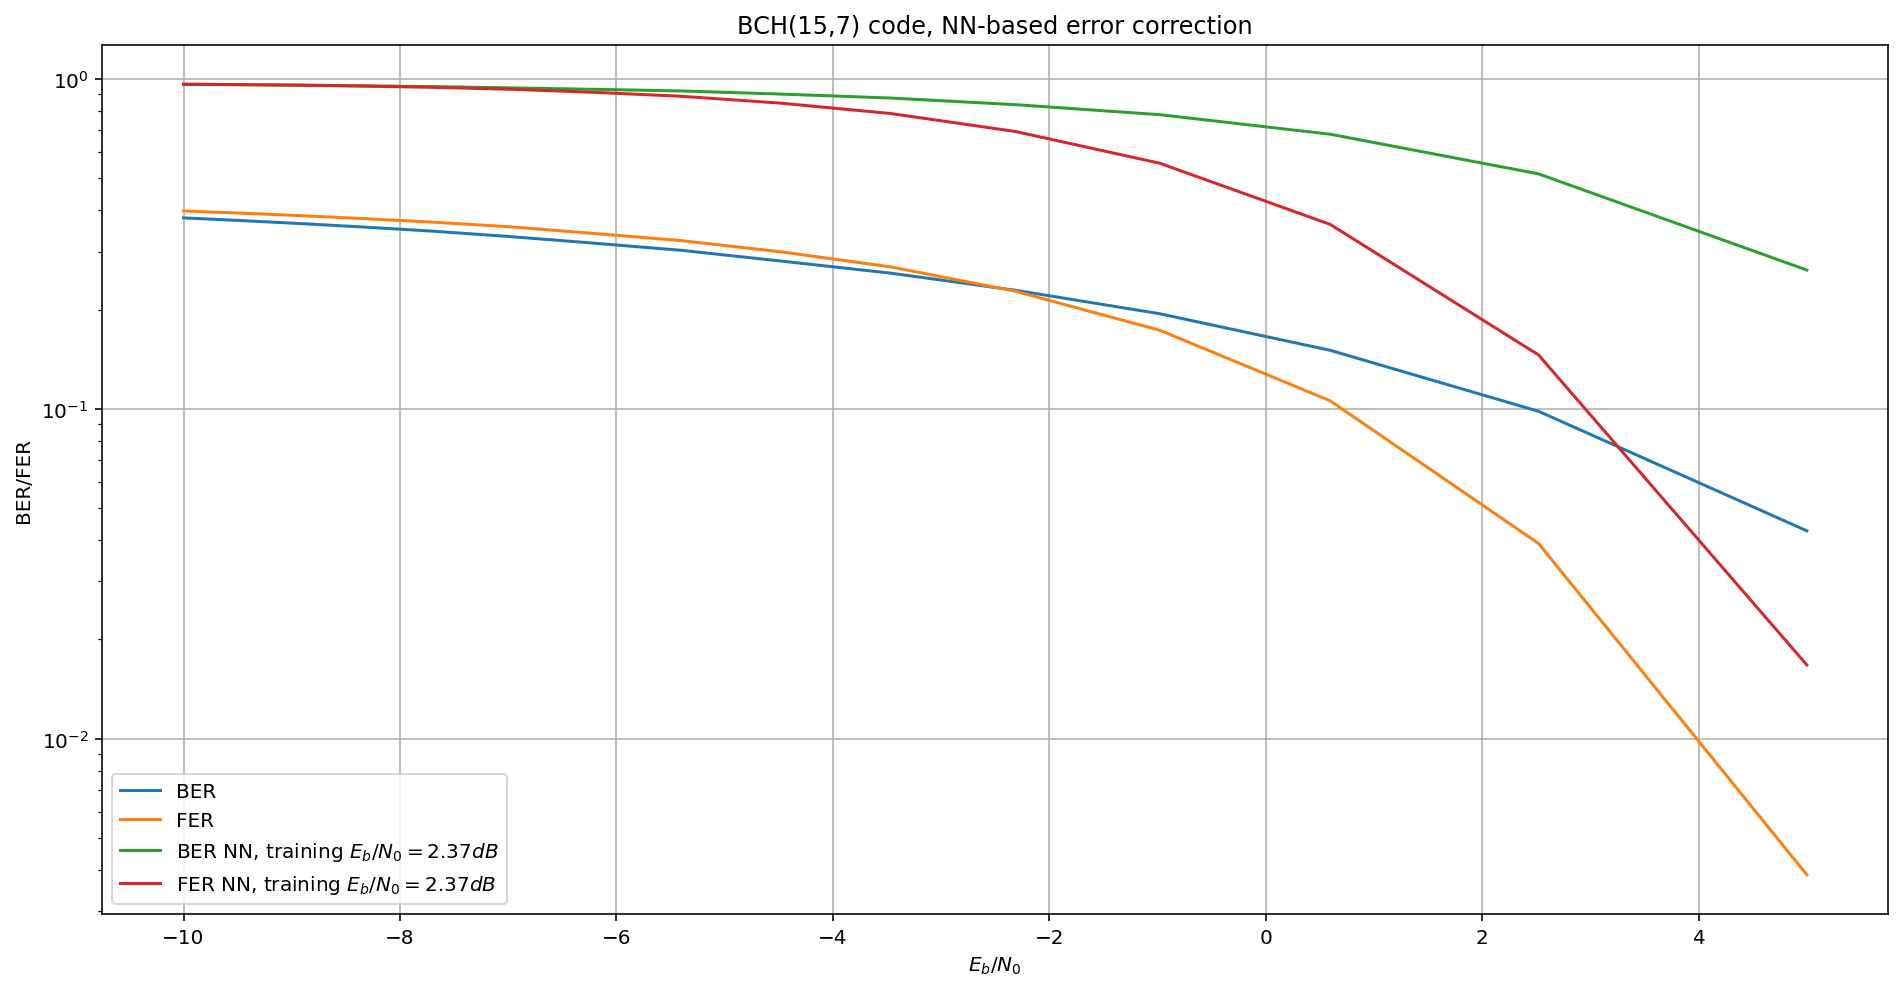

In [ ]:
plt.figure(figsize = (16, 8))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber[1])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[1])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer[1])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[1])
plt.legend(['BER',
            'FER',
            'BER NN, training $E_b/N_0 = 2.37dB$',
            'FER NN, training $E_b/N_0 = 2.37dB$'])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(15,7) code, NN-based error correction')
plt.grid()

Previous model was trained on the random set of codewords. Now let's compare performance of models trained on random set of codewords and on zero-codeword

# Compare models trained on random set and on zero-codeword

In [ ]:
# Define set of test SNRs
SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 10
SNR_points = 15

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

In [ ]:
# base params
mode = 'gru'

train_size = 100000
validation_size = 10000

checkpoint_filepath = "chkpt_gru_zw"




test_batch = 100000
n_upd = 1         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nb_errors = np.zeros((2,len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((2,len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((2,len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((2,len(sigmas)),dtype=int)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.0001)

for set_mode_i, set_mode in enumerate([False, True]):      # Random/zero codeword selection
    
    checkpoint_filepath+=str(set_mode)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_weights_only=True,
      monitor='val_loss',
      mode='min',
      save_best_only=True)
    
#     Fit model
    # model = update_model(mode)
    for fit_iter in range(n_upd):
    #     _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, zero=set_mode)
    #     model.fit(
    #         {"synd_input": synd_input_train, "abs_input": abs_input_train},
    #         error_vectors_train,
    #         epochs=nb_epoch,
    #         batch_size=2048,
    #         validation_split = 0.2,
    #         shuffle=True, 
    #         verbose=0, 
    #         callbacks=[TqdmCallback(verbose=0), reduce_lr, model_checkpoint_callback])
        
        codewords_val, y_val, synd_input_val, abs_input_val, _ = gen_set(size=validation_size)
        codewords_denoised = (demodulateBPSK(y_val) + np.round(model.predict({"synd_input": synd_input_val, "abs_input": abs_input_val})).astype(int)) % 2
        nb_errors_NN_val = np.sum(np.not_equal(codewords_val[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(nb_errors_NN_val)
    
    # The model weights (that are considered the best) are loaded into the model.
    model.load_weights(checkpoint_filepath)
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nb_frame_errors[set_mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nb_frame_errors_NN[set_mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nb_errors[set_mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nb_errors_NN[set_mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{set_mode_i+1}/2 mode, {sig_i+1}/{len(sigmas)} test', end='\r')

2589
2562


NotFoundError: ignored

In [ ]:
# base params
mode = 'gru_simplified'

train_size = 100000
validation_size = 10000

checkpoint_filepath = 'checkpoint_gru_simpified'

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True)


test_batch = 100000
n_upd = 1         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nb_errors = np.zeros((2,len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((2,len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((2,len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((2,len(sigmas)),dtype=int)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.0001)

for set_mode_i, set_mode in enumerate([False, True]):      # Random/zero codeword selection
#     Fit model
    model = update_model(mode)
    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, zero=set_mode)
        model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            validation_split = 0.2,
            shuffle=True, 
            verbose=0, 
            callbacks=[TqdmCallback(verbose=0), reduce_lr, model_checkpoint_callback])
        
        codewords_val, y_val, synd_input_val, abs_input_val, _ = gen_set(size=validation_size)
        codewords_denoised = (demodulateBPSK(y_val) + np.round(model.predict({"synd_input": synd_input_val, "abs_input": abs_input_val})).astype(int)) % 2
        nb_errors_NN_val = np.sum(np.not_equal(codewords_val[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(nb_errors_NN_val)
    
    # The model weights (that are considered the best) are loaded into the model.
    model.load_weights(checkpoint_filepath)
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nb_frame_errors[set_mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nb_frame_errors_NN[set_mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nb_errors[set_mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nb_errors_NN[set_mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{set_mode_i+1}/2 mode, {sig_i+1}/{len(sigmas)} test', end='\r')

0epoch [00:00, ?epoch/s]

2650


0epoch [00:00, ?epoch/s]

2658


In [ ]:
# base params
mode = 'gru'

train_size = 10000
validation_size = 10000

test_batch = 100000
n_upd = 4         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nb_errors = np.zeros((2,len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((2,len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((2,len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((2,len(sigmas)),dtype=int)


for set_mode_i, set_mode in enumerate([False, True]):      # Random/zero codeword selection
#     Fit model
    model = update_model(mode)
    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, zero=set_mode)
        model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            verbose=0, 
            callbacks=[TqdmCallback(verbose=0)])
        
        codewords_val, y_val, synd_input_val, abs_input_val, _ = gen_set(size=validation_size)
        codewords_denoised = (demodulateBPSK(y_val) + np.round(model.predict({"synd_input": synd_input_val, "abs_input": abs_input_val})).astype(int)) % 2
        nb_errors_NN = np.sum(np.not_equal(codewords_val[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(nb_errors_NN)

# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nb_frame_errors[set_mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nb_frame_errors_NN[set_mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nb_errors[set_mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nb_errors_NN[set_mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{set_mode_i+1}/2 mode, {sig_i+1}/{len(sigmas)} test', end='\r')


0epoch [00:00, ?epoch/s]

7897


0epoch [00:00, ?epoch/s]

KeyboardInterrupt: ignored

In [ ]:
ber = nb_errors / (test_batch * k)
ber_nn = nb_errors_NN / (test_batch * k)
fer = nb_frame_errors / test_batch
fer_nn = nb_frame_errors_NN / test_batch

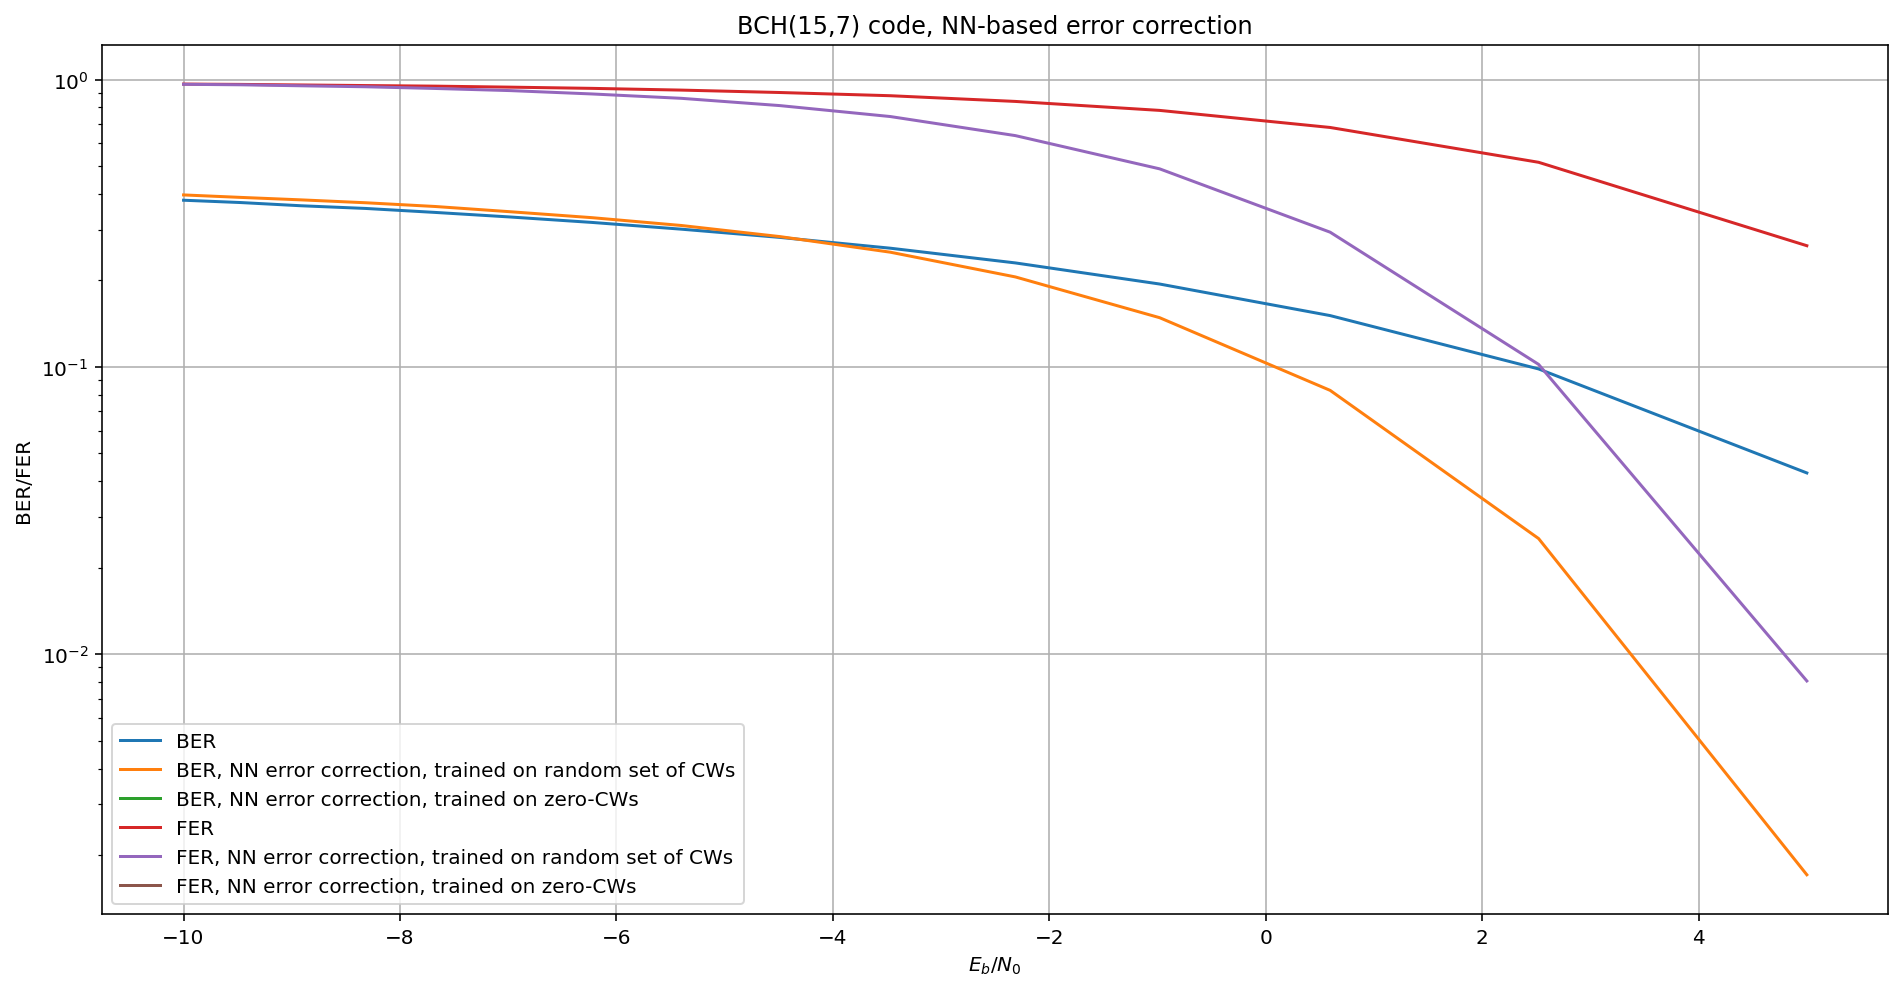

In [ ]:
plt.figure(figsize = (16, 8))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber[0])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[0])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[1])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer[0])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[0])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[1])
plt.legend(['BER',
            'BER, NN error correction, trained on random set of CWs',
            'BER, NN error correction, trained on zero-CWs',
            'FER',
            'FER, NN error correction, trained on random set of CWs',
            'FER, NN error correction, trained on zero-CWs'])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(15,7) code, NN-based error correction')
plt.grid()

# Compare parformance of models with different complexity

In [20]:
# Define set of test SNRs
SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 10
SNR_points = 15

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

In [21]:
# base params
mode = ['h-dense', 'gru_simplified', 'gru']

train_size = 100000
test_batch = 100000
n_upd = 1        # Number of training set regenerations per single model fit
nb_epoch = 128    # Number of epochs per single fit procedure

nb_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)

for mode_i, mode_val in enumerate(mode):      # Random/zero codeword selection

    checkpoint_filepath = "tmp_" + str(mode_val)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_weights_only=True,
      monitor='val_loss',
      mode='min',
      save_best_only=True)
#     Fit model


    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.0001)
    model = update_model(mode_val)
    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, zero=True)
        model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            validation_split = 0.2,
            verbose=0, 
            callbacks=[TqdmCallback(verbose=0), reduce_lr, model_checkpoint_callback])
    model.load_weights(checkpoint_filepath)
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nb_frame_errors[mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nb_frame_errors_NN[mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nb_errors[mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nb_errors_NN[mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{mode_i+1}/2 mode, {sig_i+1}/{len(sigmas)} test', end='\r')


0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

In [47]:
# base params
mode = ['h-dense', 'gru_simplified', 'gru']

train_size = 100000
test_batch = 100000
n_upd = 1        # Number of training set regenerations per single model fit
nb_epoch = 128    # Number of epochs per single fit procedure

nb_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)

for mode_i, mode_val in enumerate(mode):      # Random/zero codeword selection

    checkpoint_filepath = "tmp_" + str(mode_val)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_weights_only=True,
      monitor='val_loss',
      mode='min',
      save_best_only=True)
#     Fit model


    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.0001)
    model = update_model(mode_val)
    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size, zero=False)
        model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            validation_split = 0.2,
            verbose=0, 
            callbacks=[TqdmCallback(verbose=0), reduce_lr, model_checkpoint_callback])
    model.load_weights(checkpoint_filepath)
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nb_frame_errors[mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nb_frame_errors_NN[mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nb_errors[mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nb_errors_NN[mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{mode_i+1}/2 mode, {sig_i+1}/{len(sigmas)} test', end='\r')


0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

KeyboardInterrupt: ignored

In [40]:
for sig_i, sigma in enumerate(sigmas):
        codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
        codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

        nb_frame_errors[mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
        nb_frame_errors_NN[mode_i][sig_i] = np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
        nb_errors[mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
        nb_errors_NN[mode_i][sig_i] = np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
        print(f'{mode_i+1}/2 mode, {sig_i+1}/{len(sigmas)} test', end='\r')


In [22]:
ber = nb_errors / (test_batch * k)
ber_nn = nb_errors_NN / (test_batch * k)
fer = nb_frame_errors / test_batch
fer_nn = nb_frame_errors_NN / test_batch

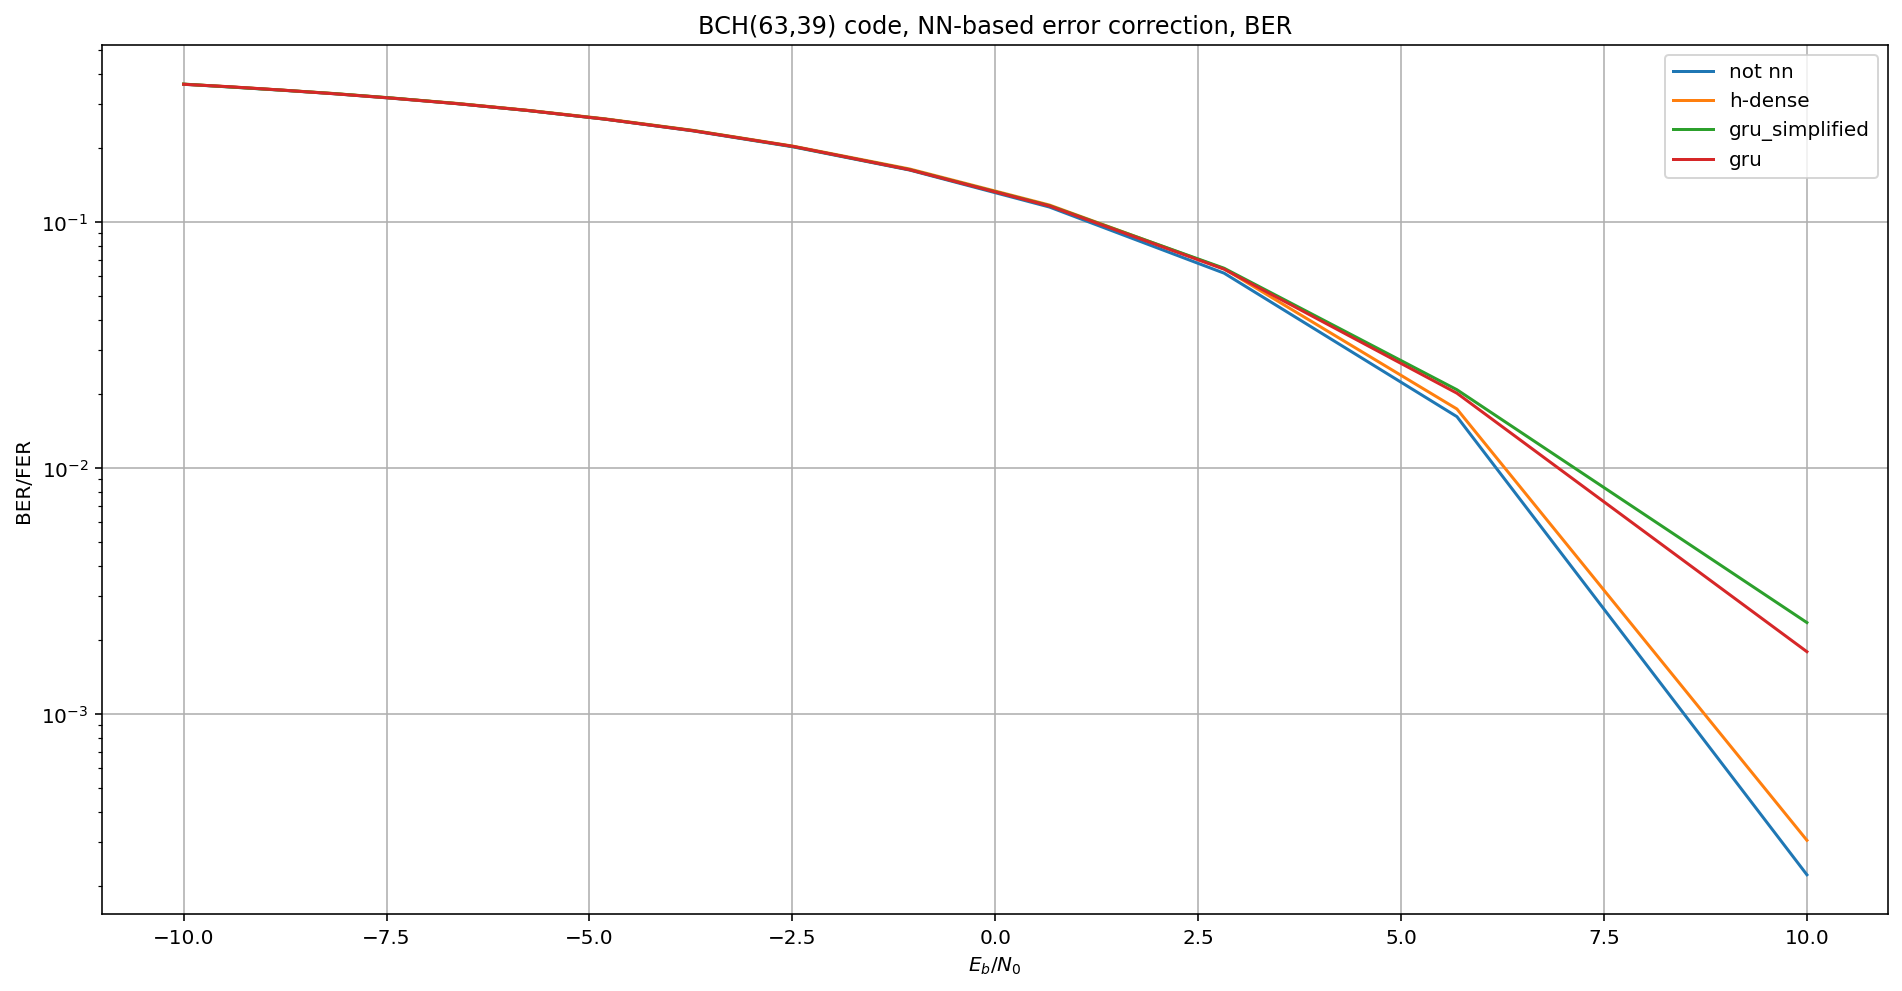

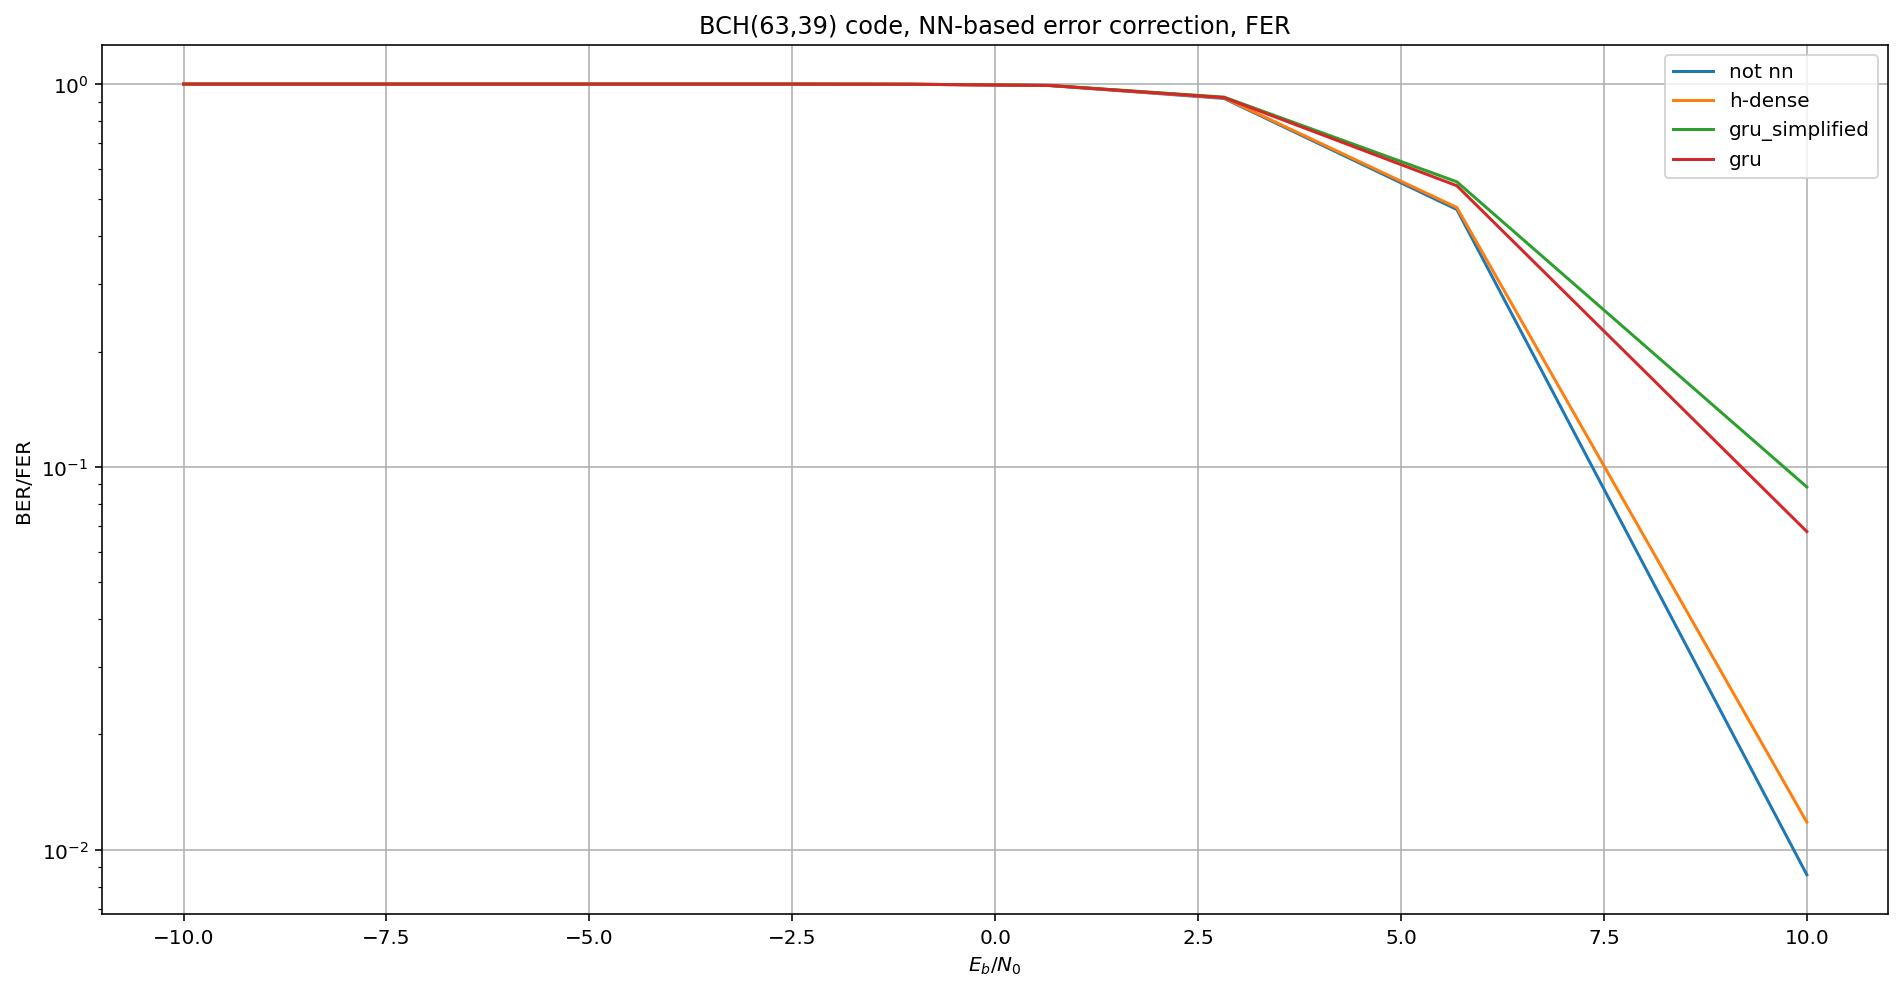

In [23]:
plt.figure(figsize = (16, 8))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber[0])
for m, _ in enumerate(mode):
  plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[m])
plt.legend(['not nn'] + mode)
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(63,39) code, NN-based error correction, BER')
plt.grid()

plt.figure(figsize = (16, 8))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer[0])
for m, _ in enumerate(mode):
  plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[m])
plt.legend(['not nn'] + mode)
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(63,39) code, NN-based error correction, FER')
plt.grid()

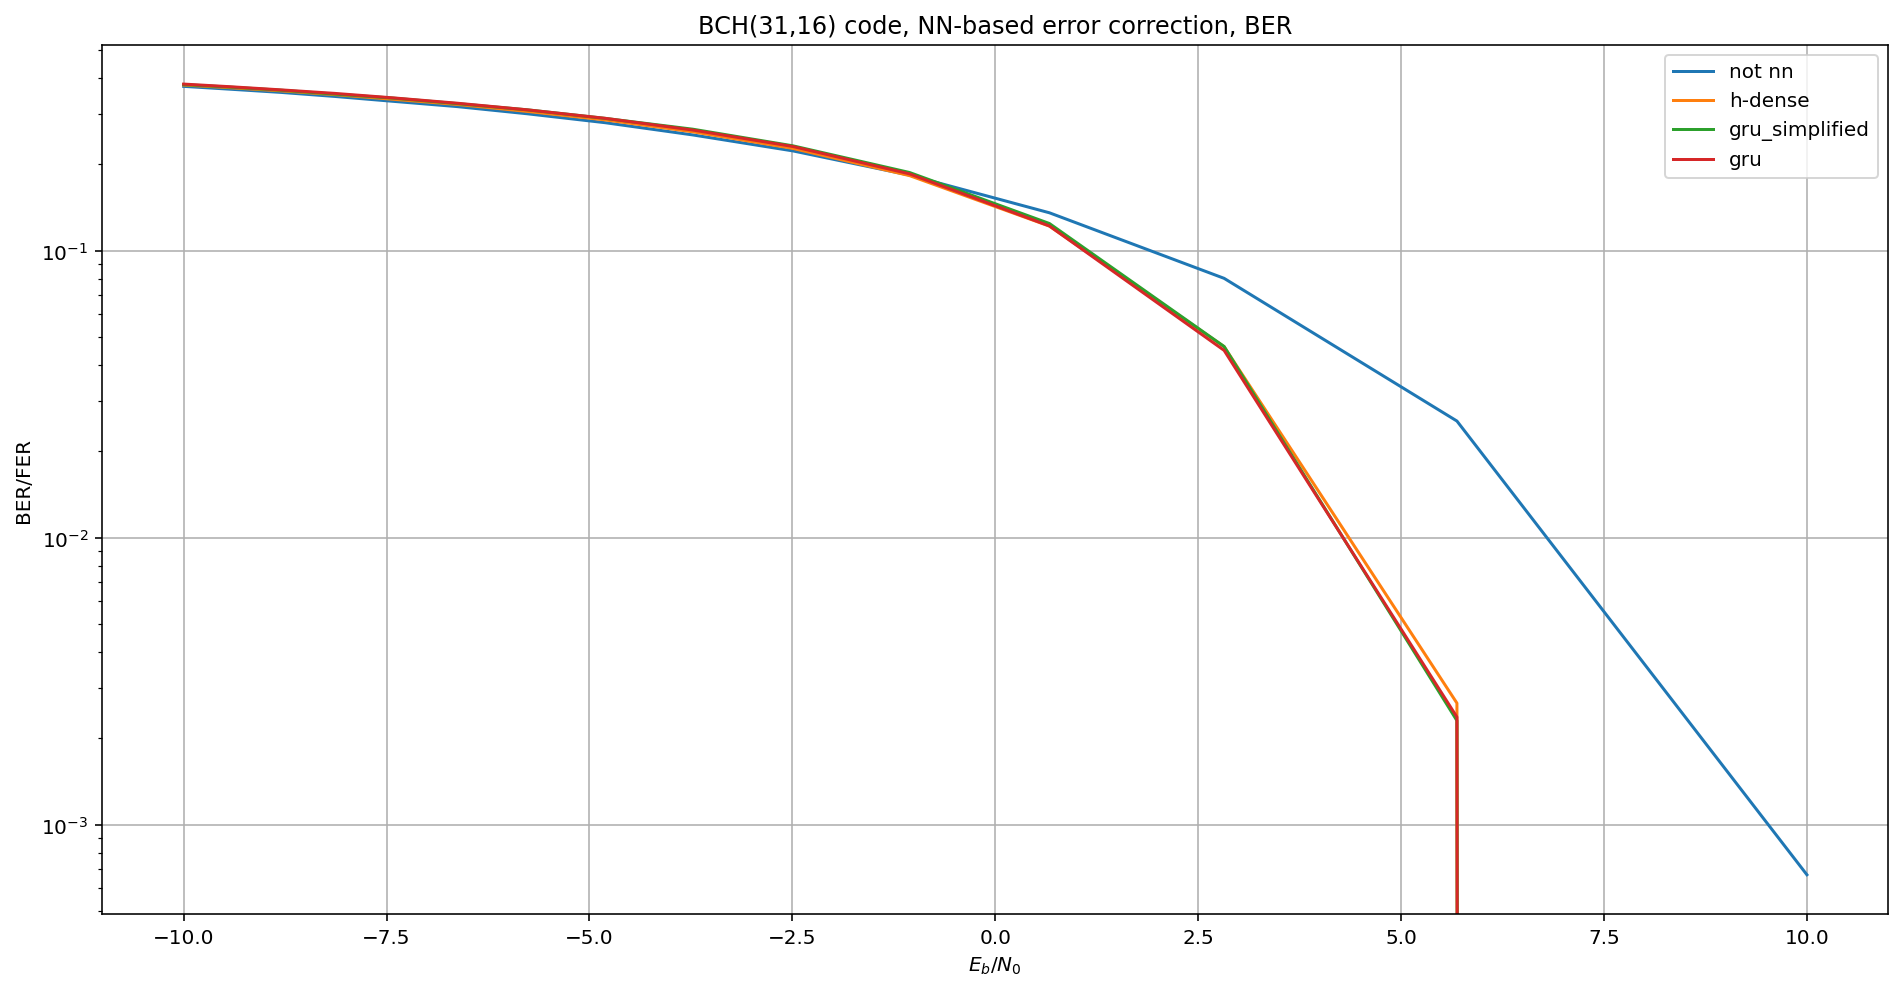

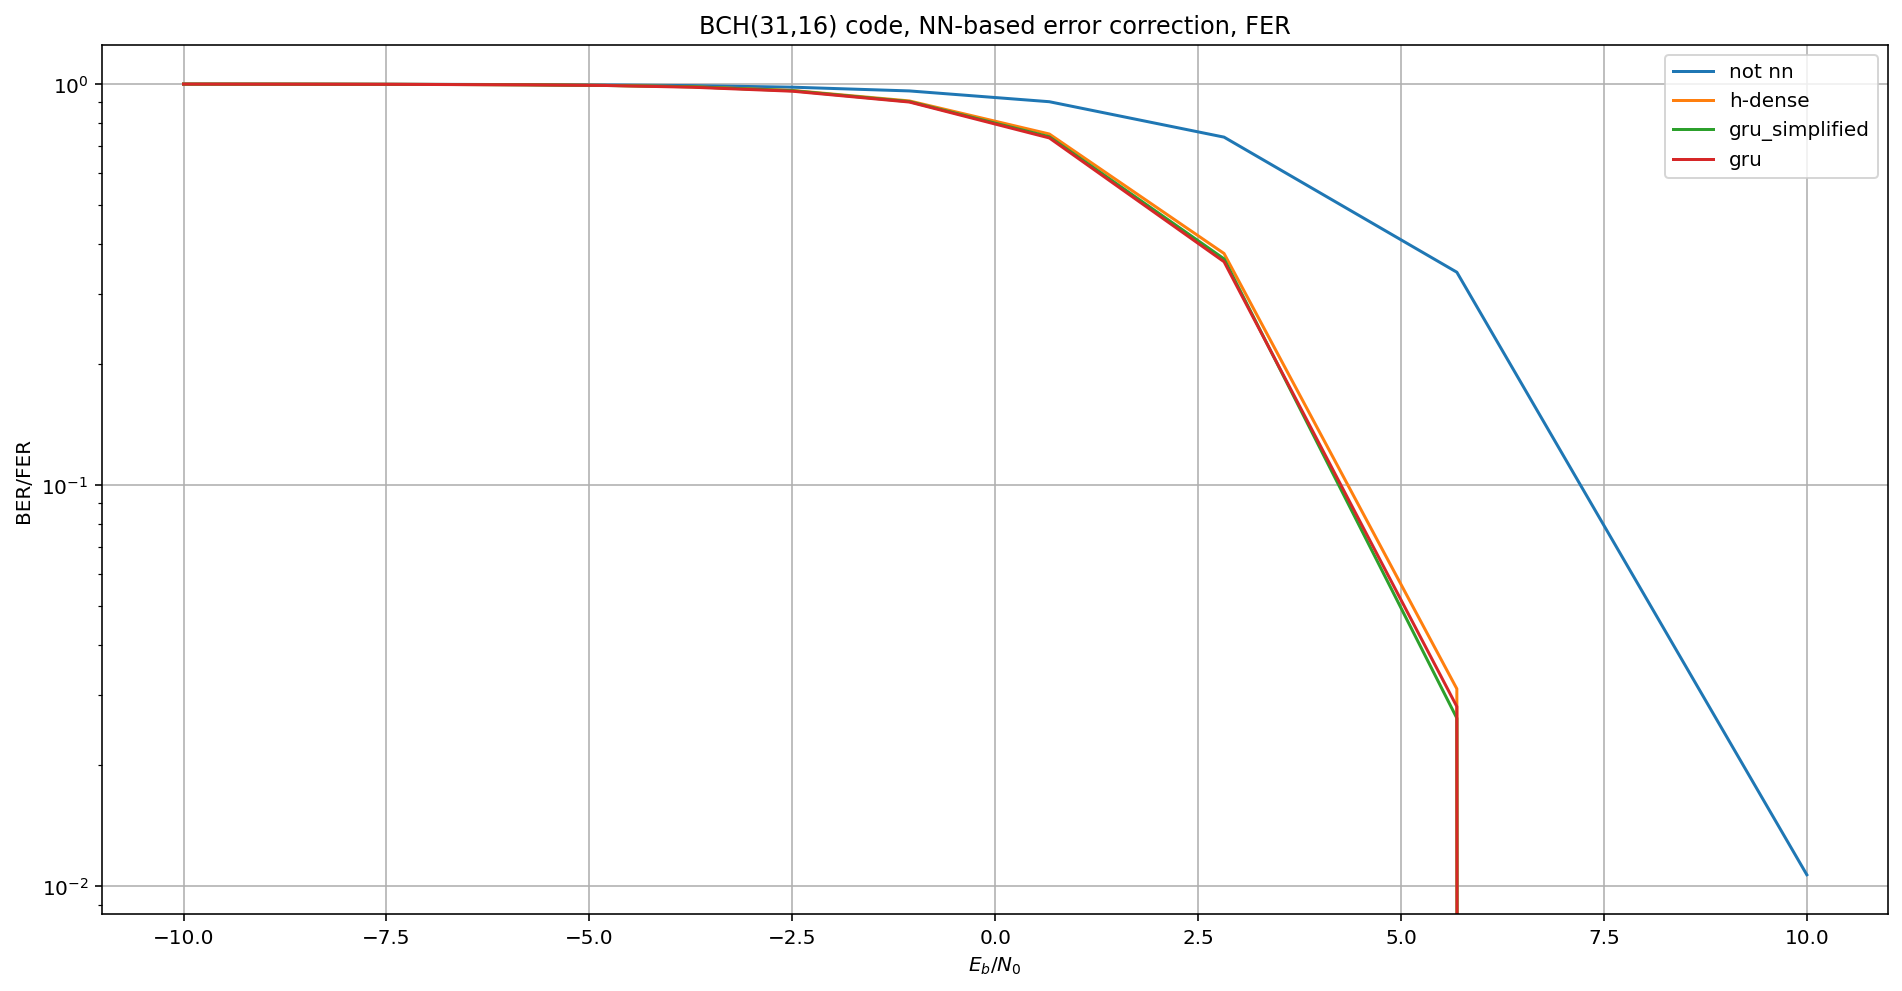

In [16]:
plt.figure(figsize = (16, 8))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber[0])
for m, _ in enumerate(mode):
  plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[m])
plt.legend(['not nn'] + mode)
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(31,16) code, NN-based error correction, BER')
plt.grid()

plt.figure(figsize = (16, 8))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer[0])
for m, _ in enumerate(mode):
  plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[m])
plt.legend(['not nn'] + mode)
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(31,16) code, NN-based error correction, FER')
plt.grid()

# Compare parformance of NN based model with ML decoder

In [ ]:
# Define set of test SNRs
SNR_dB_start_Eb = -5
SNR_dB_stop_Eb = 10
SNR_points = 20

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

In [ ]:
# base params
mode = ['h-dense']

train_size = 10000
# test_batch = 1000000
test_batch = 1000
req_nb_errors = 250
n_upd = 10         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nb_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frames = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_bits = np.zeros((len(mode),len(sigmas)),dtype=int)

for mode_i, mode_val in enumerate(mode):      # Random/zero codeword selection
#     Fit model
    model = update_model(mode_val)
    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size)
        model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            verbose=0, 
            callbacks=[TqdmCallback(verbose=0)])
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        while (nb_errors_NN[mode_i][sig_i] < req_nb_errors):
            codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
            codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

            nb_frame_errors[mode_i][sig_i] += np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
            nb_frame_errors_NN[mode_i][sig_i] += np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
            nb_errors[mode_i][sig_i] += np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
            nb_errors_NN[mode_i][sig_i] += np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
            nb_frames[mode_i][sig_i] += test_batch
            nb_bits[mode_i][sig_i] += test_batch * k
            print(f'{mode_i+1}/{len(mode)} mode, {sig_i+1}/{len(sigmas)} test, {nb_errors_NN[mode_i][sig_i]}/{req_nb_errors} errors        ', end='\r')


0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

In [ ]:
ber = nb_errors / nb_bits
ber_nn = nb_errors_NN / nb_bits
fer = nb_frame_errors / nb_frames
fer_nn = nb_frame_errors_NN / nb_frames

In [ ]:
snr_ml = np.loadtxt('../source/BCH_15_7_2_ML.txt', delimiter=',')[:,0]
ber_ml = np.loadtxt('../source/BCH_15_7_2_ML.txt', delimiter=',')[:,1]

In [ ]:
synd_nn_ber = np.loadtxt('../results/BCH/NN_syndrome_BCH157_-10_5_ber.txt')
synd_nn_fer = np.loadtxt('../results/BCH/NN_syndrome_BCH157_-10_5_fer.txt')
synd_nn_sigmas = np.loadtxt('../results/BCH/NN_syndrome_BCH157_-10_5_sigmas.txt')

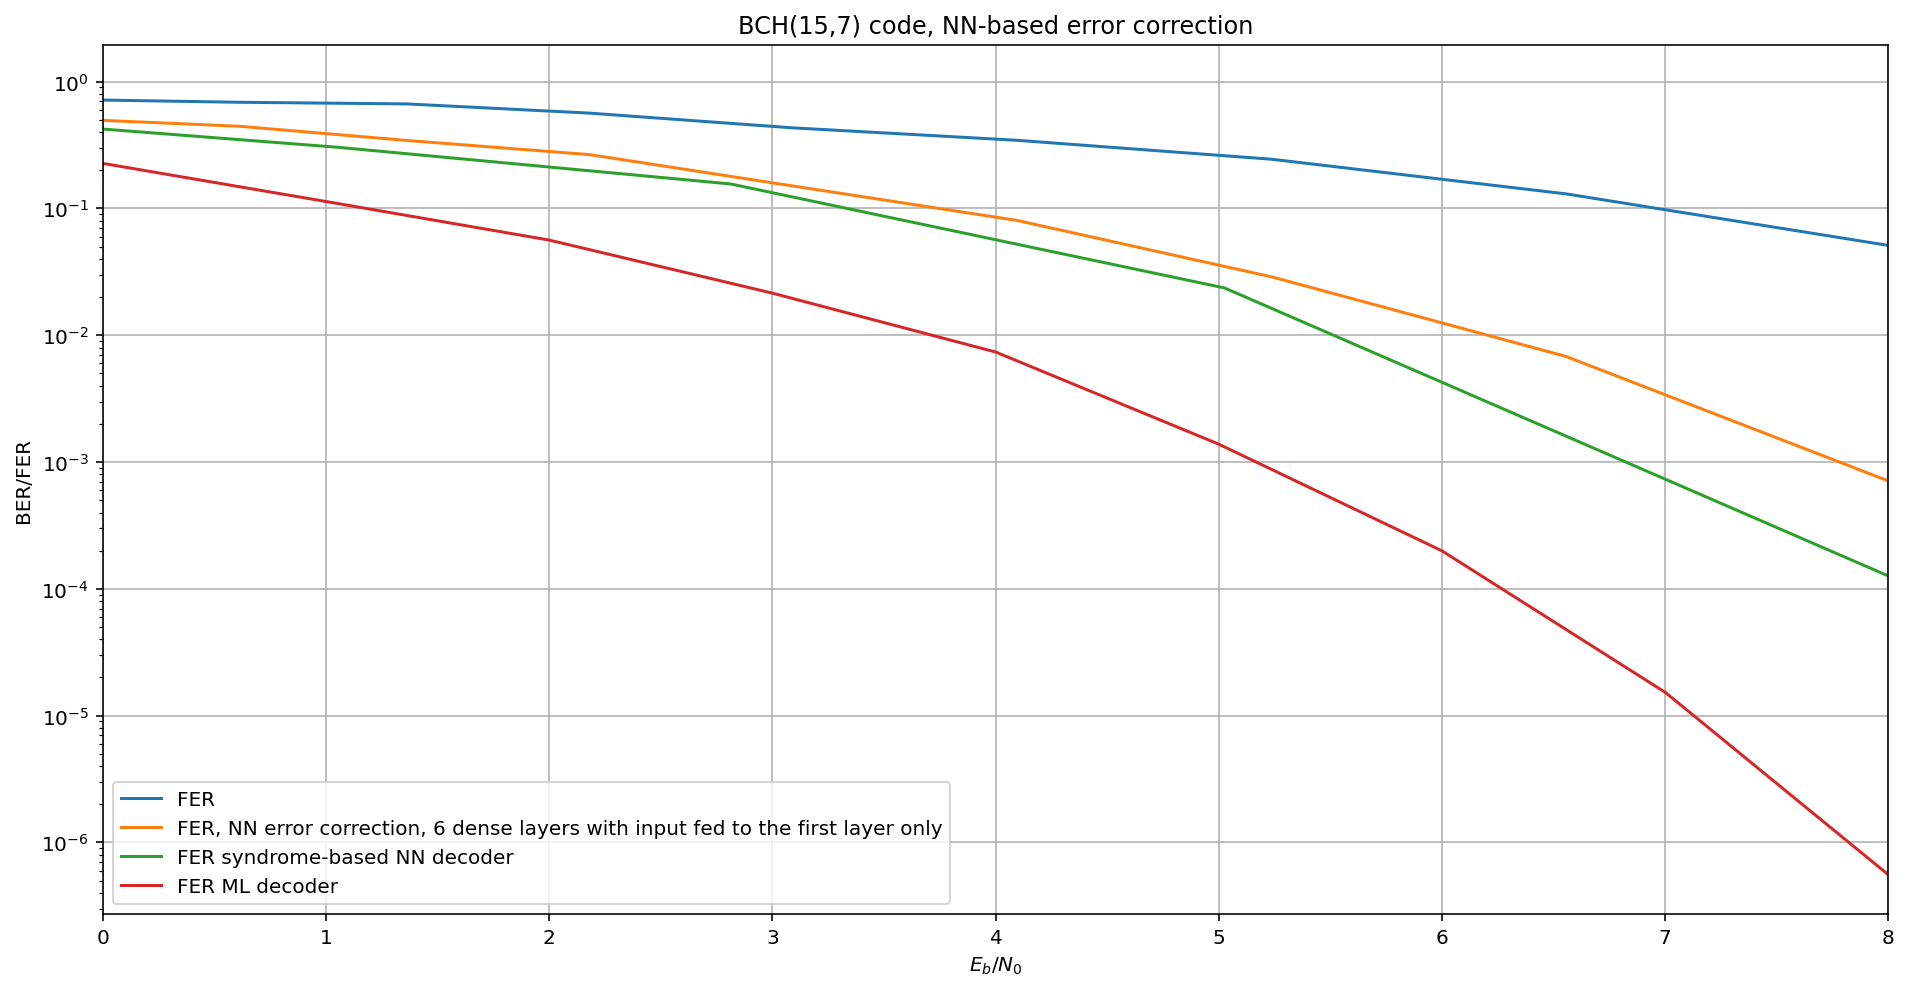

In [ ]:
plt.figure(figsize = (16, 8))
# plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber[0])
# plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[0])
# plt.plot(10*np.log10(1/(2*synd_nn_sigmas**2)) - 10*np.log10(k/N), synd_nn_ber)

plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer[0])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[0])
plt.plot(10*np.log10(1/(2*synd_nn_sigmas**2)) - 10*np.log10(k/N), synd_nn_fer)
plt.plot(snr_ml, ber_ml)
plt.legend([
#             'BER',
#             'BER, NN error correction, 6 dense layers with input fed to the first layer only',
#             'BER syndrome-based NN decoder',
            'FER',
            'FER, NN error correction, 6 dense layers with input fed to the first layer only',
            'FER syndrome-based NN decoder',
            'FER ML decoder'])

plt.xlim([0, 8])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(15,7) code, NN-based error correction')
plt.grid()